# HALO — Marketing Assistant for Hairstylists
## Notebook 1: Data Collection & Preprocessing Pipeline
**Course:** ITAI2377 | **Group:** Icarus Squad

**Team Members:** Oyinade Balogun · Francisco Medina Diaz · Rodrigo Sierra · Katherine Stanton

---

### About This Notebook
This notebook builds the complete knowledge base that powers HALO's responses.
It must be fully run before Notebooks 2 or 3 can be used.

### What This Notebook Does
| Step | Purpose |
|---|---|
| 1 | Install all required libraries |
| 2 | Mount Google Drive and import libraries |
| 2.5 | Automatically scrape articles from a URL list |
| 2.6 | Generate synthetic content using the Gemini/OpenAI API |
| 2.7 | Summarize total data collected before processing |
| 3 | Load all source documents from the knowledge base folder |
| 4 | Clean and normalize text while preserving beauty vocabulary |
| 5 | Split documents into overlapping chunks (400 words, 50-word overlap) |
| 6 | Engineer 5 metadata features per chunk for filtered retrieval |
| 7 | Generate quality metrics and visualizations |
| 8 | Generate sentence embeddings using all-MiniLM-L6-v2 |
| 9 | Store all chunks and embeddings in ChromaDB on Google Drive |
| 10 | Run retrieval sanity check with 5 test queries |
| 11 | Export processed chunks to CSV |
| 12 | Feature importance analysis |

### Notebook Structure
| Notebook | Purpose |
|---|---|
| **Notebook 1** | Data collection, preprocessing, ChromaDB storage (this notebook) |
| **Notebook 2** | RAG pipeline, Gemini API integration, evaluation framework |
| **Notebook 3** | Polished Gradio frontend interface |

### Google Drive Setup for Team Members
If this is your first time running this notebook:
1. Open Google Drive
2. Click **Shared with me** in the left sidebar
3. Right click **HALO_Project** → **Organize** → **Add shortcut to Drive**
4. Place the shortcut in **My Drive** root
5. The notebook will then find the shared folder automatically

### Prerequisites
- Add your free `GEMINI_API_KEY` (or `OPENCODE_API_KEY`) to Colab Secrets before running Step 2.6
- Get a free key at Google AI Studio — no credit card needed
- Use a **T4 GPU** runtime for faster embedding generation (Runtime → Change runtime type)

---
## Step 1 — Install Dependencies

**Cell explanation:** This cell installs all Python libraries needed for this notebook.
New libraries added compared to a standard setup include `trafilatura` for web scraping,
`beautifulsoup4` for HTML parsing, and generative AI SDKs for synthetic content generation.
Run this cell once at the start of every new Colab session.

In [1]:
# Cell 1: Install Dependencies
!pip install --upgrade pip -q

# Install specific requests version first to resolve initial conflict
!pip install -q requests==2.32.4

# Fix opentelemetry conflicts by pinning all related packages to 1.38.0
!pip install -q opentelemetry-api==1.38.0 opentelemetry-sdk==1.38.0 opentelemetry-proto==1.38.0 opentelemetry-exporter-otlp-proto-common==1.38.0 opentelemetry-exporter-otlp-proto-grpc==1.38.0 opentelemetry-exporter-otlp-proto-http==1.38.0

# Install other packages
!pip install -q chromadb sentence-transformers nltk spacy langchain \
    matplotlib seaborn pandas numpy tqdm groq beautifulsoup4 trafilatura

# Enforce requests version again just in case another package upgraded it
!pip install -q requests==2.32.4

!python -m spacy download en_core_web_sm -q

import nltk
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)

print('All dependencies installed successfully.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 22.6 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
All dependencies installed successfully.


---
## Step 2 — Imports & Mount Google Drive

**Cell explanation:** This cell imports all required Python libraries and mounts
Google Drive so the notebook can read from and write to the shared HALO project
folder. All project files — source documents, processed chunks, the vector
database, and visualizations — are stored on Drive so every team member has
access to the same data.

The `BASE_DIR` variable defines the root path for the entire project. It must
match across all three notebooks. If a team member has added a Drive shortcut
to the shared folder (see setup instructions above), this path works for everyone
without any changes.

In [2]:
# Cell 2: Imports & Mount Google Drive
import os, re, json, csv, time, datetime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from collections import Counter
import requests
from bs4 import BeautifulSoup
import trafilatura
from typing import List, Dict, Optional, Any, Set

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
import spacy
nlp = spacy.load('en_core_web_sm')

from sentence_transformers import SentenceTransformer
import chromadb
from groq import Groq

from google.colab import userdata, drive
drive.mount('/content/drive')

# Must match BASE_DIR in Notebooks 2 and 3
BASE_DIR = '/content/drive/MyDrive/HALO_Project'

for folder in ['knowledge_base', 'processed_chunks', 'chromadb',
               'evaluation', 'visualizations', 'logs']:
    os.makedirs(f'{BASE_DIR}/{folder}', exist_ok=True)

print(f'Drive mounted successfully.')
print(f'Working directory: {BASE_DIR}')
print(f'All project subfolders confirmed.')

Mounted at /content/drive
Drive mounted successfully.
Working directory: /content/drive/MyDrive/HALO_Project
All project subfolders confirmed.


---
## Step 2.1 — Utility Functions

**Cell explanation:** This section contains all the function definitions used throughout the notebook's preprocessing pipeline. Separating them from the execution logic makes the notebook easier to read and maintain.

In [3]:
# Cell 3: Utility Functions - Web Scraping
def scrape_url(url: str, min_words: int = 150) -> str | None:
    """
    Fetches and extracts clean article text from a URL.
    Uses trafilatura as the primary extractor with BeautifulSoup as fallback.
    """
    try:
        downloaded = trafilatura.fetch_url(url)
        if downloaded:
            text = trafilatura.extract(
                downloaded,
                include_comments=False,
                include_tables=False,
                no_fallback=False
            )
            if text and len(text.split()) >= min_words:
                return text.strip()

        headers = {
            'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36',
            'Accept': 'text/html,application/xhtml+xml,application/xml;q=0.9,image/webp,*/*;q=0.8',
            'Accept-Language': 'en-US,en;q=0.5'
        }
        resp = requests.get(url, headers=headers, timeout=15)
        if resp.status_code == 200:
            soup = BeautifulSoup(resp.text, 'html.parser')
            for tag in soup(['nav','footer','script','style','aside','header']):
                tag.decompose()
            paragraphs = soup.find_all('p')
            text = ' '.join(
                p.get_text(strip=True) for p in paragraphs
                if len(p.get_text(strip=True)) > 40
            )
            if len(text.split()) >= min_words:
                return text.strip()
    except Exception as e:
        print(f'    Error: {e}')
    return None

def url_to_filename(url: str) -> str:
    """
    Converts a URL into a clean descriptive filename.
    """
    domain = url.split('//')[-1].split('/')[0]
    domain = domain.replace('www.','').replace('blog.','').split('.')[0]
    slug   = url.rstrip('/').split('/')[-1]
    slug   = re.sub(r'[^a-z0-9]+', '_', slug.lower())[:40]
    return f'{domain}_{slug}.txt'

In [10]:
# Cell 4
import google.generativeai as genai

def generate_synthetic_content(topic_prompt: str, max_tokens: int = 1200, preferred_api: str = 'gemini') -> str:
    """
    Uses Gemini or OpenCode Zen to generate synthetic marketing content for the knowledge base.
    """
    system_prompt = """
    You are a professional marketing writer specializing in the beauty and hair industry.
    Write clear, practical, and engaging content for independent hairstylists.
    Use plain language — avoid jargon. Be specific and actionable.
    Do not use headers or bullet points — write in flowing paragraphs.
    Do not include any preamble like 'Here is the guide' — start writing immediately.
    """

    # Check if Gemini model is available from globals
    model = globals().get('model')
    client = globals().get('client')

    use_gemini = (preferred_api == 'gemini' and model is not None) or (not client and model is not None)
    use_opencode = (preferred_api == 'opencode' and client is not None) or (not model and client is not None)

    if use_gemini:
        # Gemini execution
        response = model.generate_content(
            f"{system_prompt}\n\nTask: {topic_prompt}",
            generation_config=genai.GenerationConfig(max_output_tokens=max_tokens)
        )
        return response.text.strip()
    elif use_opencode:
        # OpenCode Zen (OpenAI-compatible) execution
        response = client.chat.completions.create(
            model="gpt-5.4-mini", # Updated to a valid fast model from OpenCode Zen
            messages=[
                {"role": "system", "content": system_prompt},
                {"role": "user", "content": topic_prompt}
            ],
            max_tokens=max_tokens
        )
        return response.choices[0].message.content.strip()
    else:
        raise ValueError("No generative AI client is configured. Please check your API keys in Step 2.6.")

def load_documents(folder_path: str) -> List[Dict[str, Any]]:
    """
    Loads all .txt files from the knowledge base folder.
    """
    scraped_domains = ['hootsuite','sprout','later','hubspot','modernsalon',
                       'behindthechair','neilpatel','buffer']
    documents = []
    for fname in sorted(os.listdir(folder_path)):
        if not fname.endswith('.txt'):
            continue
        fpath = os.path.join(folder_path, fname)
        with open(fpath, 'r', encoding='utf-8', errors='ignore') as f:
            raw_text = f.read()
        if fname.startswith('synthetic_'):
            source_type = 'synthetic'
        elif any(d in fname for d in scraped_domains):
            source_type = 'scraped'
        else:
            source_type = 'manual'
        documents.append({
            'filename':       fname,
            'source_type':    source_type,
            'raw_text':       raw_text,
            'char_count_raw': len(raw_text),
            'word_count_raw': len(raw_text.split())
        })
    print(f'Loaded {len(documents)} source documents.')
    return documents

In [5]:
# Cell 5: Utility Functions - Text Processing & Chunking
def clean_text(text: str, protected_vocab: Set[str] = None) -> str:
    """
    Cleans and normalizes raw text while preserving beauty industry vocabulary.
    """
    if protected_vocab is None:
        protected_vocab = globals().get('PROTECTED_VOCAB', set())

    placeholders     = {}
    protected_sorted = sorted(protected_vocab, key=len, reverse=True)
    for i, term in enumerate(protected_sorted):
        token   = f'PROTECTED{i}END'
        pattern = re.compile(re.escape(term), re.IGNORECASE)
        if pattern.search(text):
            text = pattern.sub(token, text)
            placeholders[token.lower()] = term.lower()

    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'\S+@\S+\.\S+', '', text)
    text = re.sub(r'#(\w+)', r'\1', text)
    text = re.sub(r'[^a-zA-Z0-9\s\.\,\!\?\-\'\'\n]', ' ', text)
    text = re.sub(r'\n{3,}', '\n\n', text)
    text = re.sub(r' {2,}', ' ', text)
    text = text.strip().lower()

    for token, term in placeholders.items():
        text = text.replace(token, term)

    return text

def chunk_text(text: str, target_words: int = 400, overlap_words: int = 50) -> List[str]:
    """
    Splits text into overlapping chunks by word count.
    """
    words  = text.split()
    chunks = []
    start  = 0
    step   = target_words - overlap_words

    while start < len(words):
        end         = min(start + target_words, len(words))
        chunk_words = words[start:end]
        if len(chunk_words) >= 50:
            chunks.append(' '.join(chunk_words))
        start += step

    return chunks

In [6]:
# Cell 6: Utility Functions - Feature Engineering & Retrieval
def assign_platform_tag(text: str) -> str:
    tl     = text.lower()
    scores = {p: sum(1 for kw in kws if kw in tl) for p, kws in PLATFORM_KEYWORDS.items()}
    best   = max(scores, key=scores.get)
    return best if scores[best] > 0 else 'general'

def assign_season_tag(text: str) -> str:
    tl     = text.lower()
    scores = {s: sum(1 for kw in kws if kw in tl) for s, kws in SEASON_KEYWORDS.items()}
    best   = max(scores, key=scores.get)
    return best if scores[best] > 0 else 'year_round'

def assign_content_type(text: str) -> str:
    tl     = text.lower()
    scores = {ct: sum(1 for kw in kws if kw in tl) for ct, kws in CONTENT_TYPE_KEYWORDS.items()}
    best   = max(scores, key=scores.get)
    return best if scores[best] > 0 else 'educational'

def compute_domain_relevance(text: str) -> float:
    tl    = text.lower()
    words = tl.split()
    if not words: return 0.0
    hits      = sum(1 for term in BEAUTY_DOMAIN_TERMS if term.lower() in tl)
    raw_score = hits / (len(words) ** 0.5)
    return min(round(raw_score, 3), 1.0)

def assign_length_label(word_count: int) -> str:
    if word_count < 150:   return 'short'
    elif word_count < 300: return 'medium'
    else:                  return 'long'

def retrieve_chunks(query: str, n_results: int = 5, platform_filter: Optional[str] = None,
                     content_type_filter: Optional[str] = None) -> List[Dict[str, Any]]:
    query_embedding = embedding_model.encode([query]).tolist()
    if platform_filter and content_type_filter:
        where_filter = {'$and': [{'platform_tag': {'$eq': platform_filter}}, {'content_type_tag': {'$eq': content_type_filter}}]}
    elif platform_filter:
        where_filter = {'platform_tag': {'$eq': platform_filter}}
    elif content_type_filter:
        where_filter = {'content_type_tag': {'$eq': content_type_filter}}
    else:
        where_filter = None

    kwargs = {'query_embeddings': query_embedding, 'n_results': min(n_results, collection.count()), 'include': ['documents', 'metadatas', 'distances']}
    if where_filter: kwargs['where'] = where_filter

    results = collection.query(**kwargs)
    return [{
        'text': doc, 'metadata': meta, 'similarity_score': round(max(0, 1 - dist / 2), 4)
    } for doc, meta, dist in zip(results['documents'][0], results['metadatas'][0], results['distances'][0])]

---
## Step 2.5 — Automated Web Scraper

**Cell explanation:** This cell automatically fetches article text from a list of
URLs and saves each article as a `.txt` file in the `knowledge_base/` folder.
It uses `trafilatura`, a library specifically designed for extracting clean article
text from web pages — it strips navigation menus, ads, footers, and sidebars far
better than a basic HTML parser.

If trafilatura cannot extract enough text from a URL, the scraper falls back to
BeautifulSoup paragraph extraction. If that also fails, the URL is logged as
failed and skipped — the notebook continues without crashing.

A 1.5 second delay between requests is included to avoid being blocked by websites
for sending too many requests too quickly. Files already downloaded in a previous
run are skipped automatically so re-running is safe.

> **[TEAM INPUT]** Add more article URLs to `URLS_TO_SCRAPE` to increase
> your knowledge base. Aim for articles about hair and salon marketing
> from sources like Hootsuite, Sprout Social, and Later.

In [7]:
# Cell 7: Automated Web Scraper
URLS_TO_SCRAPE = [
    # Social Media Content — Instagram
    'https://blog.hootsuite.com/instagram-captions/',
    'https://blog.hootsuite.com/instagram-stories/',
    'https://blog.hootsuite.com/instagram-reels/',
    'https://blog.hootsuite.com/best-time-to-post-on-instagram/',
    'https://sproutsocial.com/insights/instagram-hashtags/',
    'https://sproutsocial.com/insights/instagram-stories/',
    'https://later.com/blog/instagram-bio/',
    'https://later.com/blog/instagram-reels/',
    'https://later.com/blog/instagram-seo/',
    'https://later.com/blog/instagram-hashtags/',
    'https://later.com/blog/instagram-strategy/',
    'https://buffer.com/library/instagram-marketing/',

    # Social Media Content — TikTok
    'https://blog.hootsuite.com/tiktok-for-business/',
    'https://blog.hootsuite.com/tiktok-hashtags/',
    'https://sproutsocial.com/insights/tiktok-marketing/',
    'https://sproutsocial.com/insights/tiktok-marketing-strategy/',
    'https://later.com/blog/tiktok-for-business/',
    'https://ads.tiktok.com/business/en/guides/salon-advertising-marketing-guide',
    'https://ads.tiktok.com/business/en-US/blog/2025-beauty-blog-tiktok-smb',
    'https://buffer.com/library/tiktok-marketing/',

    # Social Media Content — Facebook
    'https://blog.hootsuite.com/facebook-marketing-tips/',
    'https://sproutsocial.com/insights/facebook-marketing-strategy/',
    'https://sproutsocial.com/insights/facebook-algorithm/',

    # Social Media Content — Pinterest
    'https://business.pinterest.com/en-gb/blog/5-tips-drive-beauty-sales-2024/',
    'https://business.pinterest.com/blog/beginner-pinterest-content-guide',
    'https://business.pinterest.com/blog/pinterest-brand-moments-guide-2026/',
    'https://buffer.com/library/pinterest-marketing/',

    # Campaign Planning
    'https://sproutsocial.com/insights/social-media-campaign/',
    'https://blog.hootsuite.com/how-to-create-a-social-media-marketing-plan/',
    'https://later.com/blog/social-media-campaign/',
    'https://blog.hubspot.com/marketing/social-media-campaigns',
    'https://later.com/blog/how-to-make-an-instagram-marketing-campaign/',
    'https://www.salontoday.com/603990/20-proven-salon-marketing-ideas',

    # Marketing Metrics
    'https://blog.hootsuite.com/instagram-analytics/',
    'https://blog.hootsuite.com/instagram-engagement-rate/',
    'https://sproutsocial.com/insights/instagram-analytics/',
    'https://sproutsocial.com/insights/social-media-metrics/',
    'https://blog.hootsuite.com/social-media-metrics/',
    'https://later.com/blog/instagram-analytics/',

    # Salon Business & Management
    'https://www.glossgenius.com/blog/salon-marketing-ideas',
    'https://sproutsocial.com/insights/social-media-for-small-business/',
    'https://sproutsocial.com/insights/personal-branding/',
    'https://later.com/blog/instagram-growth/',
    'https://sproutsocial.com/insights/instagram-growth/',
    'https://sproutsocial.com/insights/instagram-bio/',
    'https://blog.hubspot.com/service/customer-retention-strategies',
    'https://www.salontoday.com/1093984/marketing-your-salon-effectively',

    # Content Strategy & Visuals
    'https://blog.hootsuite.com/social-media-tips/',
    'https://sproutsocial.com/insights/social-media-strategy/',
    'https://blog.hootsuite.com/user-generated-content-ugc/',
    'https://sproutsocial.com/insights/content-marketing-strategy/',
    'https://later.com/blog/instagram-reels-hacks/',
    'https://sproutsocial.com/insights/social-media-content-creation/',
    'https://blog.hootsuite.com/social-media-marketing-strategy/',
    'https://www.salontoday.com/376731/strategizing-your-salons-social-media',
    'https://www.salontoday.com/marketing-advertising/email-social-media',
    'https://blog.hubspot.com/marketing/content-pillars-for-social-media',
    'https://buffer.com/library/social-media-marketing-strategy/',

    # Local SEO & Google Business
    'https://blog.hootsuite.com/google-my-business/',
    'https://sproutsocial.com/insights/google-my-business/',
    'https://blog.hubspot.com/marketing/local-seo',
    'https://moz.com/learn/seo/local',
    'https://brightlocal.com/learn/google-business-profile/',
    'https://brightlocal.com/learn/local-seo/',
    'https://www.searchenginejournal.com/local-seo-guide/362262/',
    'https://www.brightlocal.com/learn/local-seo/local-seo-checklist/',
    'https://www.wordstream.com/blog/ws/local-seo',

    # Email & SMS Marketing
    'https://blog.hubspot.com/marketing/email-marketing-guide',
    'https://sproutsocial.com/insights/email-marketing/',
    'https://mailchimp.com/resources/email-marketing-strategy/',
    'https://mailchimp.com/resources/sms-marketing/',

    # Paid Ads & Local Advertising
    'https://ads.google.com/home/resources/how-to-advertise-on-google/',
    'https://ads.google.com/home/resources/small-business-advertising/',
    'https://www.wordstream.com/google-ads',
    'https://www.wordstream.com/facebook-ads',

    # Hair Technique, Products & Barbering
    'https://www.hairdressersjournal.com/technique/step-by-step',
    'https://www.gq.com/story/how-to-cut-your-own-hair',

    # Additional Small Business / Salon Marketing Links
    'https://later.com/blog/instagram-for-small-business/',
    'https://sproutsocial.com/insights/instagram-for-small-business/',
    'https://buffer.com/library/small-business-marketing/',
    'https://www.shopify.com/blog/small-business-marketing',
    'https://www.shopify.com/blog/marketing-plan',
    'https://www.shopify.com/blog/brand-awareness',
    'https://www.shopify.com/blog/social-media-marketing',
]

kb_path       = f'{BASE_DIR}/knowledge_base'
scrape_results = []

print(f'Scraping {len(URLS_TO_SCRAPE)} URLs...')
print('Files already downloaded will be skipped automatically.')
print('=' * 60)

for url in URLS_TO_SCRAPE:
    fname = url_to_filename(url)
    fpath = f'{kb_path}/{fname}'

    if os.path.exists(fpath):
        wc = len(open(fpath).read().split())
        print(f'  SKIP (exists): {fname} ({wc} words)')
        scrape_results.append({'url': url, 'filename': fname,
                                'status': 'skipped', 'word_count': wc})
        continue

    print(f'  Scraping: {url[:70]}...')
    text = scrape_url(url)

    if text:
        with open(fpath, 'w', encoding='utf-8') as f:
            f.write(text)
        wc = len(text.split())
        print(f'    OK: {fname} ({wc} words)')
        scrape_results.append({'url': url, 'filename': fname,
                                'status': 'success', 'word_count': wc})
    else:
        print(f'    FAILED: could not extract enough text')
        scrape_results.append({'url': url, 'filename': fname,
                                'status': 'failed', 'word_count': 0})

    time.sleep(1.5)

df_scrape  = pd.DataFrame(scrape_results)
successful = df_scrape[df_scrape['status'].isin(['success','skipped'])]
failed     = df_scrape[df_scrape['status'] == 'failed']

print(f'\nScraping complete.')
print(f'  Successful: {len(df_scrape[df_scrape["status"]=="success"])} new')
print(f'  Skipped (existed): {len(df_scrape[df_scrape["status"]=="skipped"])}')
print(f'  Failed: {len(failed)}')
print(f'  Total words collected: {successful["word_count"].sum():,}')
print(f'  Estimated chunks: ~{successful["word_count"].sum() // 350}')

if len(failed) > 0:
    print(f'\nFailed URLs (try replacing these):')
    for _, row in failed.iterrows():
        print(f'  {row["url"]}')

Scraping 84 URLs...
Files already downloaded will be skipped automatically.
  SKIP (exists): hootsuite_instagram_captions.txt (2800 words)
  SKIP (exists): hootsuite_instagram_stories.txt (2767 words)
  SKIP (exists): hootsuite_instagram_reels.txt (2517 words)
  SKIP (exists): hootsuite_best_time_to_post_on_instagram.txt (3069 words)
  SKIP (exists): sproutsocial_instagram_hashtags.txt (3743 words)
  SKIP (exists): sproutsocial_instagram_stories.txt (3257 words)
  SKIP (exists): later_instagram_bio.txt (2750 words)
  SKIP (exists): later_instagram_reels.txt (3775 words)
  SKIP (exists): later_instagram_seo.txt (1686 words)
  SKIP (exists): later_instagram_hashtags.txt (2713 words)
  SKIP (exists): later_instagram_strategy.txt (925 words)
  SKIP (exists): buffer_instagram_marketing.txt (8735 words)
  SKIP (exists): hootsuite_tiktok_for_business.txt (4561 words)
  SKIP (exists): hootsuite_tiktok_hashtags.txt (2062 words)
  SKIP (exists): sproutsocial_tiktok_marketing.txt (4292 words)
  S

---
## Step 2.6 — Synthetic Content Generator

**Cell explanation:** This cell uses the Gemini API to automatically generate
high-quality synthetic marketing content that fills gaps in the knowledge base.
Synthetic content is explicitly allowed by the midterm plan and is used here
to ensure all five HALO capabilities and all four seasons are well represented,
regardless of what articles were successfully scraped.

Each topic generates approximately 600-800 words of content, producing roughly
2 chunks per file after the chunking step. Files are saved with a `synthetic_`
prefix so they are easy to identify in the source attribution table for the report.

Files already generated in a previous run are skipped automatically. A retry mechanism
handles API rate limits gracefully to ensure all files generate over time.

> **[TEAM INPUT]** Add `GOOGLE_API_KEY` to Colab Secrets before running.
> Add more topic dicts to `SYNTHETIC_TOPICS` to generate additional content.

In [8]:
# Cell 8
!pip install -q -U google-generativeai openai
import google.generativeai as genai
from google.colab import userdata

# Load Gemini API key securely from Colab Secrets
# Get a free key at aistudio.google.com using your Google account
# No credit card required — free tier allows 1,500 requests per day
try:
    GEMINI_API_KEY = userdata.get('GEMINI_API_KEY')
except userdata.SecretNotFoundError:
    GEMINI_API_KEY = None

# Configure Gemini client if key is available
if GEMINI_API_KEY:
    genai.configure(api_key=GEMINI_API_KEY)

    # Dynamically find available models for this API key
    available_models = [m.name.replace('models/', '') for m in genai.list_models() if 'generateContent' in m.supported_generation_methods]
    print(f'Models available to your GEMINI_API_KEY: {available_models}')

    # Pick the best available model automatically
    if 'gemini-2.0-flash' in available_models:
        GEMINI_MODEL = 'gemini-2.0-flash'
    elif 'gemini-1.5-flash' in available_models:
        GEMINI_MODEL = 'gemini-1.5-flash'
    elif 'gemini-1.5-pro' in available_models:
        GEMINI_MODEL = 'gemini-1.5-pro'
    elif available_models:
        GEMINI_MODEL = available_models[0]
    else:
        GEMINI_MODEL = None

    if GEMINI_MODEL:
        model = genai.GenerativeModel(GEMINI_MODEL)
        print(f'Gemini client ready.')
        print(f'Model: {GEMINI_MODEL}')
    else:
        print('No valid generative models found.')
        model = None
else:
    print('GEMINI_API_KEY not found. Skipping initial Gemini configuration.')
    model = None

# Load Google API key (fallback)
try:
    GOOGLE_API_KEY = userdata.get('GOOGLE_API_KEY')
except userdata.SecretNotFoundError:
    GOOGLE_API_KEY = None

if GOOGLE_API_KEY:
    print('Google API key loaded.')
    # If GEMINI_API_KEY wasn't found, try setting up with GOOGLE_API_KEY
    if not GEMINI_API_KEY:
        genai.configure(api_key=GOOGLE_API_KEY)
        available_models = [m.name.replace('models/', '') for m in genai.list_models() if 'generateContent' in m.supported_generation_methods]
        print(f'Models available to your GOOGLE_API_KEY: {available_models}')

        if 'gemini-2.0-flash' in available_models:
            GEMINI_MODEL = 'gemini-2.0-flash'
        elif 'gemini-1.5-flash' in available_models:
            GEMINI_MODEL = 'gemini-1.5-flash'
        elif available_models:
            GEMINI_MODEL = available_models[0]
        else:
            GEMINI_MODEL = None

        if GEMINI_MODEL:
            model = genai.GenerativeModel(GEMINI_MODEL)
            print(f'Gemini client ready via GOOGLE_API_KEY.')
            print(f'Model: {GEMINI_MODEL}')
else:
    print('GOOGLE_API_KEY not found in secrets.')

# Configure client for OpenCode Zen
try:
    OPENCODEZEN_API_KEY = userdata.get('OPENCODE_API_KEY')
except userdata.SecretNotFoundError:
    OPENCODEZEN_API_KEY = None

if OPENCODEZEN_API_KEY:
    from openai import OpenAI
    client = OpenAI(
        api_key=OPENCODEZEN_API_KEY,
        base_url="https://opencode.ai/zen/v1"
    )
    print('OpenCode Zen client ready.')
else:
    print('OPENCODE_API_KEY not found in secrets.')

GEMINI_API_KEY not found. Skipping initial Gemini configuration.
Google API key loaded.
Models available to your GOOGLE_API_KEY: ['gemini-2.5-flash', 'gemini-2.5-pro', 'gemini-2.0-flash', 'gemini-2.0-flash-001', 'gemini-2.0-flash-lite-001', 'gemini-2.0-flash-lite', 'gemini-2.5-flash-preview-tts', 'gemini-2.5-pro-preview-tts', 'gemma-3-1b-it', 'gemma-3-4b-it', 'gemma-3-12b-it', 'gemma-3-27b-it', 'gemma-3n-e4b-it', 'gemma-3n-e2b-it', 'gemma-4-26b-a4b-it', 'gemma-4-31b-it', 'gemini-flash-latest', 'gemini-flash-lite-latest', 'gemini-pro-latest', 'gemini-2.5-flash-lite', 'gemini-2.5-flash-image', 'gemini-3-pro-preview', 'gemini-3-flash-preview', 'gemini-3.1-pro-preview', 'gemini-3.1-pro-preview-customtools', 'gemini-3.1-flash-lite-preview', 'gemini-3-pro-image-preview', 'nano-banana-pro-preview', 'gemini-3.1-flash-image-preview', 'lyria-3-clip-preview', 'lyria-3-pro-preview', 'gemini-3.1-flash-tts-preview', 'gemini-robotics-er-1.5-preview', 'gemini-robotics-er-1.6-preview', 'gemini-2.5-comp

In [12]:
# Cell 9: Synthetic Content Generator
# Each topic generates one .txt file (~600-800 words = ~2 chunks)
# Topics cover all 5 HALO capabilities and all 4 seasons
# [TEAM INPUT] Add more topics to the list if chunk count is still below 500
SYNTHETIC_TOPICS = [
    # Social Media — TikTok
    {'filename': 'synthetic_tiktok_content_ideas_hairstylists.txt',
     'prompt': 'Write a detailed guide (600-800 words) for independent hairstylists on creating effective TikTok content. Cover: what types of videos perform well (transformations, tutorials, day-in-the-life), how to use trending audio, optimal video length, captions and hashtags for TikTok specifically, and how TikTok differs from Instagram for salon marketing. Write in plain language for someone who is not a marketing expert.'},

    {'filename': 'synthetic_tiktok_hashtag_strategy.txt',
     'prompt': 'Write a guide (600-800 words) on TikTok hashtag strategy specifically for hairstylists and salon owners. Cover: how TikTok hashtags work differently from Instagram, which hashtag categories to use, examples of effective hashtags for balayage, natural hair, keratin treatments, and how many hashtags to use per video.'},

    {'filename': 'synthetic_tiktok_for_salon_beginners.txt',
     'prompt': 'Write a beginner guide (600-800 words) for hairstylists who have never used TikTok for their business. Cover: setting up a business profile, how the For You Page algorithm works in simple terms, and 5 easy first video ideas a hairstylist can film in their salon today.'},

    # Social Media — Facebook
    {'filename': 'synthetic_facebook_for_hairstylists.txt',
     'prompt': 'Write a guide (600-800 words) on using Facebook effectively for an independent hairstylist. Cover: Facebook business page setup, what posts work well, how to reach an older demographic, Facebook Groups as a community tool, and how to promote offers without paid advertising.'},

    # Engagement Content
    {'filename': 'synthetic_engagement_post_ideas.txt',
     'prompt': 'Write a guide (600-800 words) with engagement post ideas for hairstylists on Instagram and TikTok. Cover: what engagement posts are, why they matter for the algorithm, 10 specific ideas tailored to hair and beauty, and tips for writing captions that get people to comment. Include example caption text for at least 3 ideas.'},

    {'filename': 'synthetic_community_building_social_media.txt',
     'prompt': 'Write a guide (600-800 words) for hairstylists on building a loyal community on social media. Cover: the difference between followers and a community, how to respond to comments, why behind-the-scenes content matters, and 5 specific community-building tactics.'},

    # Seasonal
    {'filename': 'synthetic_spring_marketing_guide.txt',
     'prompt': 'Write a seasonal marketing guide (600-800 words) for hairstylists planning spring promotions. Cover: spring hair trends, timing, Mother Day promotion ideas, and 3 sample Instagram captions for spring content.'},

    {'filename': 'synthetic_mothers_day_promotion_guide.txt',
     'prompt': 'Write a promotion guide (600-800 words) for hairstylists running a Mother Day campaign. Cover: timing, service bundle ideas, caption writing tips, and sample text for an Instagram post, Facebook post, and client text message.'},

    {'filename': 'synthetic_summer_marketing_guide.txt',
     'prompt': 'Write a seasonal marketing guide (600-800 words) for hairstylists planning summer promotions. Cover: summer hair trends, back-to-school timing, summer caption ideas, and how to rebook summer clients before the fall slowdown.'},

    {'filename': 'synthetic_fall_marketing_guide.txt',
     'prompt': 'Write a seasonal marketing guide (600-800 words) for hairstylists planning fall promotions. Cover: fall hair color trends, Halloween and Thanksgiving content ideas, and 3 sample Instagram captions for fall content.'},

    # Client Retention
    {'filename': 'synthetic_client_retention_strategies.txt',
     'prompt': 'Write a guide (600-800 words) on client retention strategies for independent hairstylists. Cover: why retention matters more than acquisition, ideal rebooking windows, simple loyalty program ideas, and 5 things a stylist can do this week to improve retention.'},

    {'filename': 'synthetic_appointment_reminder_templates.txt',
     'prompt': 'Write a collection of appointment reminder and follow-up message templates (600-800 words) for hairstylists. Include: 48-hour reminder, same-day reminder, post-appointment thank you, 4-week color refresh reminder, 6-week cut reminder, and 3-month lapsed client re-engagement message. Write in a warm personal tone.'},

    # Competitive Positioning
    {'filename': 'synthetic_instagram_bio_guide.txt',
     'prompt': 'Write a guide (600-800 words) on writing an effective Instagram bio for an independent hairstylist. Cover: what to include, how to communicate a niche, call to action examples, and 3 example bios for different stylist types.'},

    {'filename': 'synthetic_niche_marketing_for_stylists.txt',
     'prompt': 'Write a guide (600-800 words) on niche marketing for hairstylists. Cover: common niches, why appealing to everyone hurts your brand, how to identify your niche, and how to communicate it across social media.'},

    # Instagram
    {'filename': 'synthetic_instagram_reels_guide.txt',
     'prompt': 'Write a guide (600-800 words) for hairstylists on using Instagram Reels to grow their business. Cover: why Reels get more reach, what types work best, ideal length, trending audio, and 5 specific Reel ideas.'},

    {'filename': 'synthetic_instagram_stories_guide.txt',
     'prompt': 'Write a guide (600-800 words) for hairstylists on using Instagram Stories. Cover: how Stories differ from feed posts, what to post, how often, link sticker for bookings, Story highlights, and 7 daily Story ideas.'},

    {'filename': 'synthetic_instagram_content_calendar.txt',
     'prompt': 'Write a guide (600-800 words) for hairstylists on creating a simple monthly Instagram content calendar. Cover: why planning reduces stress, how to batch create content, a sample week of posts, and how to balance promotional and non-promotional content.'},

    {'filename': 'synthetic_instagram_algorithm_explained.txt',
     'prompt': 'Write a plain-language explanation (600-800 words) of how the Instagram algorithm works for hairstylists. Cover: what signals Instagram uses, why consistency matters, realistic posting frequency, and 5 things a hairstylist can do this week to work with the algorithm.'},

    {'filename': 'synthetic_before_after_post_guide.txt',
     'prompt': 'Write a guide (600-800 words) for hairstylists on how to photograph and post before and after transformations. Cover: good before photo tips, lighting, caption information to include, and why before and after posts are the highest performing content type for hairstylists.'},

    {'filename': 'synthetic_posting_frequency_guide.txt',
     'prompt': 'Write a guide (600-800 words) for hairstylists on how often to post on Instagram and TikTok. Cover: quality versus quantity, realistic schedules for a solo stylist, best days and times to post, and how to create a sustainable routine.'},

    # Metrics
    {'filename': 'synthetic_google_business_profile_guide.txt',
     'prompt': 'Write a guide (600-800 words) for hairstylists on setting up and optimizing a Google Business Profile. Cover: why it matters, setup steps, how to ask for reviews, how to respond to reviews, and how it connects to local search.'},

    {'filename': 'synthetic_analytics_for_beginners.txt',
     'prompt': 'Write a beginner guide (600-800 words) for hairstylists who have never looked at their analytics. Cover: where to find analytics, what the important numbers mean, how to use them to decide what to post more of, and a simple monthly review routine.'},

    {'filename': 'synthetic_social_media_mistakes_stylists.txt',
     'prompt': 'Write a guide (600-800 words) on the most common social media mistakes hairstylists make and how to fix them. Cover at least 8 mistakes with explanations of why each hurts and what to do instead.'},

    # Campaign Planning
    {'filename': 'synthetic_new_year_promotion_guide.txt',
     'prompt': 'Write a seasonal marketing guide (600-800 words) for hairstylists planning New Year promotions. Cover: why January is an opportunity, new year new hair messaging, detox and refresh promotions, and caption ideas for January.'},

    {'filename': 'synthetic_valentines_day_promotion.txt',
     'prompt': 'Write a promotion guide (600-800 words) for hairstylists running a Valentine Day campaign. Cover: timing, romantic service ideas, gift card strategies, and sample Instagram caption and client text message.'},

    {'filename': 'synthetic_gift_card_promotion_guide.txt',
     'prompt': 'Write a guide (600-800 words) for hairstylists on selling gift cards. Cover: when gift cards sell best, how to package them, how to promote on social media, and 3 sample Instagram captions for different occasions.'},

    {'filename': 'synthetic_referral_program_guide.txt',
     'prompt': 'Write a guide (600-800 words) for hairstylists on creating a simple client referral program. Cover: how to structure the reward, how to tell clients about it, how to track referrals, and sample scripts for asking a happy client to refer a friend.'},

    {'filename': 'synthetic_launch_new_service_guide.txt',
     'prompt': 'Write a guide (600-800 words) for hairstylists on how to announce a new service on social media. Cover: building anticipation, the announcement post, caption writing, and a simple 2-week social media launch plan.'},

    # Retention
    {'filename': 'synthetic_consultation_guide.txt',
     'prompt': 'Write a guide (600-800 words) for hairstylists on conducting a great client consultation. Cover: questions to ask, managing expectations, documenting preferences, and how a great consultation leads to rebooking.'},

    {'filename': 'synthetic_client_communication_guide.txt',
     'prompt': 'Write a guide (600-800 words) for hairstylists on communicating professionally with clients via text and DM. Cover: response times, handling cancellations, enforcing a cancellation policy, and sample scripts for 5 common situations.'},

    {'filename': 'synthetic_building_client_loyalty.txt',
     'prompt': 'Write a guide (600-800 words) on building deep client loyalty as an independent hairstylist. Cover: the difference between a returning client and a truly loyal one, small gestures that make clients feel valued, and how loyal clients become your best marketing.'},

    # Positioning
    {'filename': 'synthetic_salon_suite_marketing.txt',
     'prompt': 'Write a guide (600-800 words) for hairstylists who work in a salon suite. Cover: how to market the privacy and luxury of a suite, one-on-one attention as a selling point, and what to show on social media that highlights the suite environment.'},

    {'filename': 'synthetic_bridal_hair_marketing.txt',
     'prompt': 'Write a guide (600-800 words) for hairstylists who want to attract more bridal clients. Cover: how to position as a bridal specialist, building a bridal portfolio on Instagram, reaching engaged clients, and handling bridal party bookings.'},

    {'filename': 'synthetic_natural_hair_specialist_marketing.txt',
     'prompt': 'Write a guide (600-800 words) for hairstylists who specialize in natural and textured hair. Cover: how to communicate expertise on social media, content that resonates with the natural hair community, and how to build trust with clients who have had bad experiences.'},

    {'filename': 'synthetic_color_specialist_marketing.txt',
     'prompt': 'Write a guide (600-800 words) for hairstylists who specialize in color services. Cover: building a color portfolio, what to include in transformation posts, how to handle color correction inquiries, and how to price color services confidently.'},

    {'filename': 'synthetic_pricing_your_services.txt',
     'prompt': 'Write a guide (600-800 words) for hairstylists on pricing their services. Cover: why underpricing hurts your business, how to research competitive pricing, how to raise prices without losing clients, and a sample price increase message.'},

    {'filename': 'synthetic_personal_brand_for_stylists.txt',
     'prompt': 'Write a guide (600-800 words) for hairstylists on building a personal brand. Cover: what a personal brand means for a solo stylist, how personality shows up in content, why being specific attracts better clients, and 5 questions to clarify your brand identity.'},

    # Additional gap fillers
    {'filename': 'synthetic_salon_photography_guide.txt',
     'prompt': 'Write a guide (600-800 words) for hairstylists on taking better photos of their work using just a smartphone. Cover: lighting, framing, background, photographing dark versus light hair, before and after tips, and free editing apps.'},

    {'filename': 'synthetic_caption_writing_guide.txt',
     'prompt': 'Write a guide (600-800 words) for hairstylists on writing compelling social media captions. Cover: why the first line matters most, how to write a hook, the difference between captions that get likes versus saves, and 5 caption frameworks a hairstylist can reuse.'},

    {'filename': 'synthetic_handling_dm_inquiries.txt',
     'prompt': 'Write a guide (600-800 words) for hairstylists on handling direct message inquiries professionally. Cover: how to respond to pricing questions, how to move from DM to booking link, and sample responses for 5 common DM scenarios.'},

    {'filename': 'synthetic_end_of_year_marketing.txt',
     'prompt': 'Write a guide (600-800 words) for hairstylists on marketing their salon from October through December. Cover: holiday party hair promotions, gift card campaigns, creating urgency around limited slots, and how to use December to set up a strong January.'},

    {'filename': 'synthetic_back_to_school_promotion.txt',
     'prompt': 'Write a guide (600-800 words) for hairstylists on running a back-to-school promotion in July and August. Cover: which services to promote, how to target students and parents, timing, caption ideas, and student discount strategies.'},

    {'filename': 'synthetic_collaboration_marketing.txt',
     'prompt': 'Write a guide (600-800 words) for hairstylists on collaborating with other local businesses. Cover: which businesses make natural partners, how to approach a collaboration, what a successful cross-promotion looks like, and how to measure results.'},

    {'filename': 'synthetic_giveaway_guide.txt',
     'prompt': 'Write a guide (600-800 words) for hairstylists on running a social media giveaway. Cover: what makes a good prize, entry requirements, how long to run it, how to promote it, and how to convert entrants into booked clients.'},

    {'filename': 'synthetic_educational_content_guide.txt',
     'prompt': 'Write a guide (600-800 words) for hairstylists on creating educational content that builds authority. Cover: why teaching expertise attracts better clients, what topics to cover, and 10 educational content ideas for this month.'},

    {'filename': 'synthetic_behind_the_scenes_content.txt',
     'prompt': 'Write a guide (600-800 words) for hairstylists on creating behind the scenes content. Cover: why it performs well, what to show, how to be authentic without oversharing, and 8 specific behind the scenes content ideas.'},

    {'filename': 'synthetic_black_friday_salon_promotion.txt',
     'prompt': 'Write a guide (600-800 words) for hairstylists on running a Black Friday or Cyber Monday promotion. Cover: why it works for gift cards and packages, how to structure an offer, how to promote it, and a sample Instagram caption and client text message.'},

    {'filename': 'synthetic_measuring_marketing_success.txt',
     'prompt': 'Write a guide (600-800 words) for hairstylists on knowing if their marketing is actually working. Cover: vanity metrics versus meaningful metrics, how to track where new clients come from, and a simple monthly marketing review routine.'},

    {'filename': 'synthetic_google_reviews_strategy.txt',
     'prompt': 'Write a guide (600-800 words) for hairstylists on building a strong Google review presence. Cover: why reviews matter, when and how to ask for one, sample scripts, how to respond to positive reviews, and how reviews connect to local search.'},

    {'filename': 'synthetic_content_batching_guide.txt',
     'prompt': 'Write a guide (600-800 words) for hairstylists on batching social media content. Cover: what batching means, how to set aside one session per week, what to photograph during a busy day, and free tools for scheduling posts in advance.'},

    {'filename': 'synthetic_hashtag_strategy_instagram.txt',
     'prompt': 'Write a comprehensive guide (600-800 words) on Instagram hashtag strategy for hairstylists. Cover: how hashtags work, niche versus broad hashtags, how many to use, where to put them, and a sample hashtag set for 5 different types of hair posts.'},

    {'filename': 'synthetic_video_content_guide.txt',
     'prompt': 'Write a guide (600-800 words) for hairstylists on creating video content with just a smartphone. Cover: camera settings, lighting tips, how to film a transformation, simple free editing apps, and why video outperforms photos for reach.'},

    {'filename': 'synthetic_email_marketing_basics.txt',
     'prompt': 'Write a guide (600-800 words) for hairstylists on using email or text marketing to stay in touch with clients. Cover: why owning your contact list matters, free tools for simple campaigns, what to send and how often, and how to grow your list.'},

    {'filename': 'synthetic_social_proof_guide.txt',
     'prompt': 'Write a guide (600-800 words) for hairstylists on using social proof to attract new clients. Cover: what social proof means, how to encourage client tags, how to repost client content ethically, and how real client results build more trust than promotional content.'},

    {'filename': 'synthetic_location_tagging_strategy.txt',
     'prompt': 'Write a guide (600-800 words) for hairstylists on using location tags and local SEO on social media. Cover: how location tags work, why tagging your city matters, how to use local hashtags, and a simple local visibility checklist.'},

    {'filename': 'synthetic_handling_negative_reviews.txt',
     'prompt': 'Write a guide (600-800 words) for hairstylists on handling negative reviews professionally. Cover: why your response matters more than the review, the right tone, a step by step approach, how to take the conversation offline, and how to use feedback to improve.'},
]

kb_path           = f'{BASE_DIR}/knowledge_base'
synthetic_results = []

print(f'Generating {len(SYNTHETIC_TOPICS)} synthetic content files...')
print('Files already generated will be skipped automatically.')
print('=' * 60)

# Initialize the preferred API depending on availability
current_api = 'gemini' if globals().get('model') else 'opencode'

for topic in tqdm(SYNTHETIC_TOPICS, desc='Generating'):
    fpath = f'{kb_path}/{topic["filename"]}'

    if os.path.exists(fpath):
        wc = len(open(fpath).read().split())
        synthetic_results.append({
            'filename': topic['filename'],
            'status': 'skipped',
            'word_count': wc
        })
        continue

    max_retries = 3
    for attempt in range(max_retries):
        try:
            text = generate_synthetic_content(topic['prompt'], preferred_api=current_api)
            with open(fpath, 'w', encoding='utf-8') as f:
                f.write(text)
            wc = len(text.split())
            synthetic_results.append({
                'filename': topic['filename'],
                'status': 'success',
                'word_count': wc
            })
            # Wait 5 seconds to be safe from rate limits on both Gemini and OpenCode Zen.
            time.sleep(5)
            break # Break out of the retry loop if successful
        except Exception as e:
            # Handling rate limits (429) gracefully for both APIs
            if '429' in str(e) or 'Quota' in str(e) or 'rate limit' in str(e).lower():
                print(f'\n  Rate limit hit for {current_api}. Switching API...')
                # Toggle API key on rate limit hit
                current_api = 'opencode' if current_api == 'gemini' else 'gemini'
                time.sleep(5) # Shorter sleep before immediate retry with alternate API
            else:
                print(f'\n  ERROR on {topic["filename"]}: {e}')
                synthetic_results.append({
                    'filename': topic['filename'],
                    'status': 'failed',
                    'word_count': 0
                })
                break # Break out of the retry loop if it's a different error
    else:
        # Executed if the loop completes without breaking (meaning it failed all retries)
        print(f'\n  Failed to generate {topic["filename"]} after {max_retries} attempts.')
        synthetic_results.append({
            'filename': topic['filename'],
            'status': 'failed',
            'word_count': 0
        })

df_synthetic = pd.DataFrame(synthetic_results)
successful_s = df_synthetic[df_synthetic['status'].isin(['success','skipped'])]
print(f'\nSynthetic generation complete.')
print(f'  New files generated: {len(df_synthetic[df_synthetic["status"]=="success"])}')
print(f'  Files skipped (existed): {len(df_synthetic[df_synthetic["status"]=="skipped"])}')
print(f'  Total words: {successful_s["word_count"].sum():,}')
print(f'  Estimated chunks: ~{successful_s["word_count"].sum() // 350}')

Generating 56 synthetic content files...
Files already generated will be skipped automatically.


Generating: 100%|██████████| 56/56 [00:00<00:00, 132.41it/s]


Synthetic generation complete.
  New files generated: 0
  Files skipped (existed): 56
  Total words: 28,394
  Estimated chunks: ~81


---
## Step 2.7 — Data Collection Summary

**Cell explanation:** This cell counts all `.txt` files now in the knowledge base
folder and estimates the total chunk count before the preprocessing pipeline runs.
It categorizes files as manual (uploaded by team members), scraped (from Step 2.5),
or synthetic (generated in Step 2.6).

If the estimated chunk count is below 500, the cell prints how many more chunks
are needed and suggests adding more URLs to Step 2.5 or more topics to Step 2.6.
Re-run Steps 2.5, 2.6, and 2.7 as many times as needed before proceeding.

In [13]:
# Cell 10: Data Collection Summary
kb_path    = f'{BASE_DIR}/knowledge_base'
all_files  = [f for f in os.listdir(kb_path) if f.endswith('.txt')]

scraped_domains = ['hootsuite','sprout','later','hubspot','modernsalon',
                   'hootsuite','behindthechair','neilpatel','buffer']

synthetic_files = [f for f in all_files if f.startswith('synthetic_')]
scraped_files   = [f for f in all_files if not f.startswith('synthetic_')
                   and any(d in f for d in scraped_domains)]
manual_files    = [f for f in all_files if f not in synthetic_files
                   and f not in scraped_files]

total_words = sum(
    len(open(f'{kb_path}/{f}', encoding='utf-8', errors='ignore').read().split())
    for f in all_files
)
est_chunks = total_words // 350

print('KNOWLEDGE BASE COLLECTION SUMMARY')
print('=' * 50)
print(f'Manual files (team uploaded):  {len(manual_files)}')
print(f'Scraped files (auto):          {len(scraped_files)}')
print(f'Synthetic files (AI Gen):      {len(synthetic_files)}')
print(f'Total files:                   {len(all_files)}')
print(f'\nTotal words across all files:  {total_words:,}')
print(f'Estimated chunks after split:  ~{est_chunks}')

if est_chunks < 500:
    needed = (500 - est_chunks) * 350
    print(f'\nSTILL NEEDED: ~{500 - est_chunks} more chunks (~{needed:,} words)')
    print('Add more URLs to Step 2.5 or topics to Step 2.6 and re-run.')
else:
    print(f'\nChunk target (500-800) met. Proceed to Step 3.')

KNOWLEDGE BASE COLLECTION SUMMARY
Manual files (team uploaded):  42
Scraped files (auto):          56
Synthetic files (AI Gen):      56
Total files:                   154

Total words across all files:  286,051
Estimated chunks after split:  ~817

Chunk target (500-800) met. Proceed to Step 3.


---
## Step 3 — Load All Source Documents

**Cell explanation:** This cell loads every `.txt` file from the knowledge base
folder into memory as a list of document dictionaries. Each dictionary contains
the filename, raw text content, word count, and source type (manual, scraped,
or synthetic).

This step runs the same regardless of how files were collected — manually uploaded,
scraped by Step 2.5, or generated by Step 2.6. All files are treated equally
by the preprocessing pipeline.

In [14]:
# Cell 11: Load All Source Documents
documents = load_documents(f'{BASE_DIR}/knowledge_base')

df_docs = pd.DataFrame([{
    'File':  d['filename'],
    'Type':  d['source_type'],
    'Words': d['word_count_raw']
} for d in documents])
print('\nLoaded Documents (first 20):')
display(df_docs.head(20))
print(f'\nSource type breakdown:')
print(df_docs['Type'].value_counts().to_string())

Loaded 154 source documents.

Loaded Documents (first 20):


,File,Type,Words
0,ads_2025_beauty_blog_tiktok_smb.txt,manual,883
1,ads_google_ads_tips.txt,manual,157
2,ads_how_to_advertise_on_google.txt,manual,419
3,ads_salon_advertising_marketing_guide.txt,manual,1787
4,ads_small_business_advertising.txt,manual,419
5,allure_best_hair_oils.txt,manual,3910
6,brightlocal_google_business_profile.txt,manual,334
7,brightlocal_local_seo.txt,manual,367
8,brightlocal_local_seo_checklist.txt,manual,5348
9,buffer_instagram_marketing.txt,scraped,8735



Source type breakdown:
Type
scraped      56
synthetic    56
manual       42


---
## Step 4 — Text Cleaning & Normalization

**Cell explanation:** This cell standardizes all raw text so the embedding model
processes it consistently. Raw text from different sources — websites, PDFs copied
to text, handwritten templates — has inconsistent formatting including extra
whitespace, URLs, emoji characters, hashtag symbols, and special characters.

The cleaning function works in 8 steps:
1. Replace protected beauty vocabulary with placeholder tokens
2. Remove URLs and email addresses
3. Remove hashtag symbols while keeping the word
4. Remove non-alphanumeric characters except basic punctuation
5. Normalize whitespace
6. Convert everything to lowercase
7. Restore protected vocabulary in its original form

**Why the protected vocabulary list matters:** Standard text cleaning would alter
or remove specialty hair terms like `balayage`, `co-wash`, `ombre`, and `locs`.
The protected list ensures these terms survive cleaning unchanged because they
are critical for the domain relevance scoring in Step 6.

In [15]:
# Cell 12: Define Protected Beauty Vocabulary
# 60+ beauty and hair industry terms protected from text normalization
# [TEAM INPUT] Add more terms as you find them in your source documents
PROTECTED_VOCAB = {
    # Color techniques
    'balayage','ombre','sombre','highlights','lowlights','babylights',
    'foilayage','color correction','color refresh','toner','gloss','glaze',
    'bleach','lightener','double process','single process','root touch-up','root shadow',
    # Texture & treatment
    'keratin','keratin treatment','brazilian blowout','relaxer','texturizer','perm',
    'co-wash','co wash','cowash','deep conditioning','protein treatment',
    'bond builder','olaplex','k18',
    # Natural & textured hair
    'loc','locs','dreadlocks','protective styles','protective styling',
    'box braids','knotless braids','twist out','wash and go',
    'natural hair','afro','coily','kinky',
    'type 4c','type 4b','type 4a','type 3c','type 3b','type 3a',
    # Cuts & styling
    'blowout','blowdry','blow dry','updo','bridal hair',
    'curtain bangs','wolf cut','shag','razor cut','scissor over comb','taper','fade',
    # Business / salon
    'salon suite','booth rental','chair rental','solo stylist','independent stylist',
    'commission stylist','consultation','rebooking','retention','upsell','add-on service',
    # Platforms
    'instagram','tiktok','facebook','pinterest','google business',
    'reels','stories','feed post','carousel',
    # Marketing metrics
    'engagement rate','reach','impressions','ctr','click-through rate',
    'conversion','follower growth','saves','shares',
}

print(f'Protected vocabulary loaded: {len(PROTECTED_VOCAB)} terms')

Protected vocabulary loaded: 92 terms


In [16]:
# Cell 13: Apply Text Cleaning & Normalization Function
for doc in documents:
    doc['clean_text']       = clean_text(doc['raw_text'], PROTECTED_VOCAB)
    doc['word_count_clean'] = len(doc['clean_text'].split())
    doc['char_count_clean'] = len(doc['clean_text'])

print('Text cleaning complete.')
sample = documents[0]
print(f"\nSample: {sample['filename']}")
print(f"  Before: {sample['word_count_raw']} words")
print(f"  After:  {sample['word_count_clean']} words")
print(f"\n  Raw excerpt:   {sample['raw_text'][:200]}")
print(f"\n  Clean excerpt: {sample['clean_text'][:200]}")

Text cleaning complete.

Sample: ads_2025_beauty_blog_tiktok_smb.txt
  Before: 883 words
  After:  893 words

  Raw excerpt:   Data-backed insights, content tips, and campaign strategies for small-to-medium beauty brands ready to level up.
Beauty is evolving- and small to medium businesses (SMBs) are leading the glow-up. In 2

  Clean excerpt: data-backed insights, content tips, and campaign strategies for small-to-medium beauty brands ready to level up.
beauty is evolving- and small to medium businesses smbs are leading the glow-up. in 202


---
## Step 5 — Text Chunking with Overlap

**Cell explanation:** This cell splits each cleaned document into smaller,
bite-sized pieces called chunks. Chunking is necessary because the RAG system
retrieves individual chunks at query time — a full 2,000-word article is too
large and unfocused to retrieve usefully. Smaller chunks let the system return
only the most relevant portion for each question.

**Parameters (from the midterm plan):**
- Target chunk size: 400 words
- Overlap between consecutive chunks: 50 words

The 50-word overlap ensures that sentences falling at the boundary between two
chunks are not cut off and lost. Each chunk shares its last 50 words with the
first 50 words of the next chunk, preserving context across boundaries.

Chunks with fewer than 50 words are discarded as they contain too little
information to be useful for retrieval.

In [17]:
# Cell 14: Text Chunking with Overlap
all_chunks = []
for doc in documents:
    chunks = chunk_text(doc['clean_text'])
    for i, chunk in enumerate(chunks):
        all_chunks.append({
            'chunk_id':    f"{doc['filename'].replace('.txt','')}_chunk_{i:03d}",
            'source_file': doc['filename'],
            'source_type': doc['source_type'],
            'chunk_index': i,
            'text':        chunk,
            'word_count':  len(chunk.split())
        })

wc_list = [c['word_count'] for c in all_chunks]
print(f'Chunking complete.')
print(f'  Total chunks:   {len(all_chunks)}')
print(f'  Average size:   {sum(wc_list)/len(wc_list):.0f} words')
print(f'  Min / Max:      {min(wc_list)} / {max(wc_list)} words')

if len(all_chunks) < 500:
    print(f'\n  Below 500 target. Add more files and re-run from Step 3.')
else:
    print(f'\n  Chunk target met. Proceed to Step 6.')

Chunking complete.
  Total chunks:   884
  Average size:   370 words
  Min / Max:      50 / 400 words

  Chunk target met. Proceed to Step 6.


---
## Step 6 — Feature Engineering: Metadata Tagging

**Cell explanation:** This cell adds 5 structured metadata labels to every chunk.
This is the feature engineering step — it transforms raw text chunks into
structured, searchable records by adding domain-specific attributes.

These tags are stored alongside each chunk in ChromaDB and enable filtered
retrieval in Notebooks 2 and 3. For example, when a user asks for TikTok
content ideas, the retrieval system filters for `platform_tag = tiktok` chunks
before running similarity search, dramatically improving relevance.

| Feature | Type | Purpose |
|---|---|---|
| `platform_tag` | Categorical | Which social platform the chunk applies to |
| `season_tag` | Categorical | Time of year or event relevance |
| `content_type_tag` | Categorical | Intent: Promotional, Educational, Engagement, Retention |
| `domain_relevance_score` | Numeric (0-1) | How beauty-specific the chunk is (>0.7 = prioritized) |
| `length_label` | Categorical | Guides AI response length: short / medium / long |

In [18]:
# Cell 15: Feature Engineering: Metadata Tagging
# Keyword dictionaries used to assign platform, season, and content type tags
# Each tag is assigned based on which keywords appear most frequently in the chunk
PLATFORM_KEYWORDS = {
    'instagram': ['instagram','ig','reels','stories','feed post','carousel','bio link'],
    'tiktok':    ['tiktok','tik tok','short video','for you page','fyp','duet'],
    'facebook':  ['facebook','fb','facebook page','facebook group'],
    'google_business': ['google business','google my business','gmb','google reviews'],
    'pinterest': ['pinterest','pin','board'],
}
SEASON_KEYWORDS = {
    'spring': ['spring','easter',"mother's day",'mothers day','april','may'],
    'summer': ['summer','june','july','august','back-to-school','vacation'],
    'fall':   ['fall','autumn','september','october','halloween','thanksgiving'],
    'winter': ['winter','holiday','christmas','new year','december','january','valentine'],
}
CONTENT_TYPE_KEYWORDS = {
    'promotional': ['discount','offer','deal','sale','promotion','special','gift card',
                    'package','limited time','booking','book now','appointment'],
    'educational': ['how to','tips','guide','tutorial','explain','what is',
                    'learn','understand','technique','method'],
    'engagement':  ['question','poll','comment','share','tag a friend','community',
                    'would you','what do you think','let us know','this or that'],
    'retention':   ['rebooking','follow-up','loyalty','returning','welcome back',
                    'remind','reminder','rebook','client message','missed you'],
}
BEAUTY_DOMAIN_TERMS = list(PROTECTED_VOCAB) + [
    'hairstylist','stylist','salon','hair','color','cut','style',
    'client','appointment','beauty','scalp','shampoo','conditioner',
    'brush','scissors','foil','flat iron','curling iron','hairspray','serum'
]

# Apply all 5 features to every chunk
for chunk in all_chunks:
    t = chunk['text']
    chunk['platform_tag']           = assign_platform_tag(t)
    chunk['season_tag']             = assign_season_tag(t)
    chunk['content_type_tag']       = assign_content_type(t)
    chunk['domain_relevance_score'] = compute_domain_relevance(t)
    chunk['length_label']           = assign_length_label(chunk['word_count'])

df_chunks = pd.DataFrame(all_chunks)
print(f'Feature engineering complete.')
print(f'5 features assigned to all {len(all_chunks)} chunks.')
display(df_chunks[[
    'chunk_id','source_type','platform_tag','season_tag',
    'content_type_tag','domain_relevance_score','length_label'
]].head(10))

Feature engineering complete.
5 features assigned to all 884 chunks.


,chunk_id,source_type,platform_tag,season_tag,content_type_tag,domain_relevance_score,length_label
0,ads_2025_beauty_blog_tiktok_smb_chunk_000,manual,instagram,year_round,educational,0.200,long
1,ads_2025_beauty_blog_tiktok_smb_chunk_001,manual,instagram,summer,educational,0.250,long
2,ads_2025_beauty_blog_tiktok_smb_chunk_002,manual,instagram,year_round,engagement,0.144,medium
3,ads_google_ads_tips_chunk_000,manual,instagram,spring,promotional,0.161,medium
4,ads_how_to_advertise_on_google_chunk_000,manual,instagram,year_round,promotional,0.100,long
5,ads_how_to_advertise_on_google_chunk_001,manual,instagram,year_round,educational,0.115,short
6,ads_salon_advertising_marketing_guide_chunk_000,manual,instagram,year_round,promotional,0.350,long
7,ads_salon_advertising_marketing_guide_chunk_001,manual,instagram,year_round,promotional,0.550,long
8,ads_salon_advertising_marketing_guide_chunk_002,manual,instagram,year_round,promotional,0.500,long
9,ads_salon_advertising_marketing_guide_chunk_003,manual,instagram,year_round,educational,0.700,long


---
## Step 7 — Data Quality Metrics & Visualizations

**Cell explanation:** This step calculates before-and-after quality metrics
showing the impact of the preprocessing pipeline and generates visualizations
of the knowledge base composition. These charts and metrics are required by
the assignment rubric and should be included in the final report.

Six charts are generated:
1. Chunks by source type (manual vs scraped vs synthetic)
2. Platform tag distribution
3. Content type distribution (pie chart)
4. Season tag distribution
5. Domain relevance score histogram
6. Chunk word count distribution

In [19]:
# Cell 16: Data Quality Metrics
# Before/After quality metrics
metrics = []
for doc in documents:
    metrics.append({
        'File':        doc['filename'][:35],
        'Type':        doc['source_type'],
        'Raw Words':   doc['word_count_raw'],
        'Clean Words': doc['word_count_clean'],
        'Reduction %': round(
            (doc['word_count_raw'] - doc['word_count_clean'])
            / max(doc['word_count_raw'], 1) * 100, 1
        )
    })

df_metrics = pd.DataFrame(metrics)
display(df_metrics.head(20))
print(f"\n  Total raw words:       {df_metrics['Raw Words'].sum():,}")
print(f"  Total clean words:     {df_metrics['Clean Words'].sum():,}")
print(f"  Average reduction:     {df_metrics['Reduction %'].mean():.1f}%")
print(f"  Total chunks:          {len(all_chunks)}")
print(f"  Avg domain relevance:  {df_chunks['domain_relevance_score'].mean():.3f}")
print(f"  High-relevance (>0.7): {(df_chunks['domain_relevance_score'] > 0.7).sum()} chunks")

,File,Type,Raw Words,Clean Words,Reduction %
0,ads_2025_beauty_blog_tiktok_smb.txt,manual,883,893,-1.1
1,ads_google_ads_tips.txt,manual,157,155,1.3
2,ads_how_to_advertise_on_google.txt,manual,419,425,-1.4
3,ads_salon_advertising_marketing_gui,manual,1787,1787,0.0
4,ads_small_business_advertising.txt,manual,419,425,-1.4
5,allure_best_hair_oils.txt,manual,3910,3980,-1.8
6,brightlocal_google_business_profile,manual,334,346,-3.6
7,brightlocal_local_seo.txt,manual,367,380,-3.5
8,brightlocal_local_seo_checklist.txt,manual,5348,5476,-2.4
9,buffer_instagram_marketing.txt,scraped,8735,8913,-2.0



  Total raw words:       286,051
  Total clean words:     290,712
  Average reduction:     -1.1%
  Total chunks:          884
  Avg domain relevance:  0.209
  High-relevance (>0.7): 10 chunks


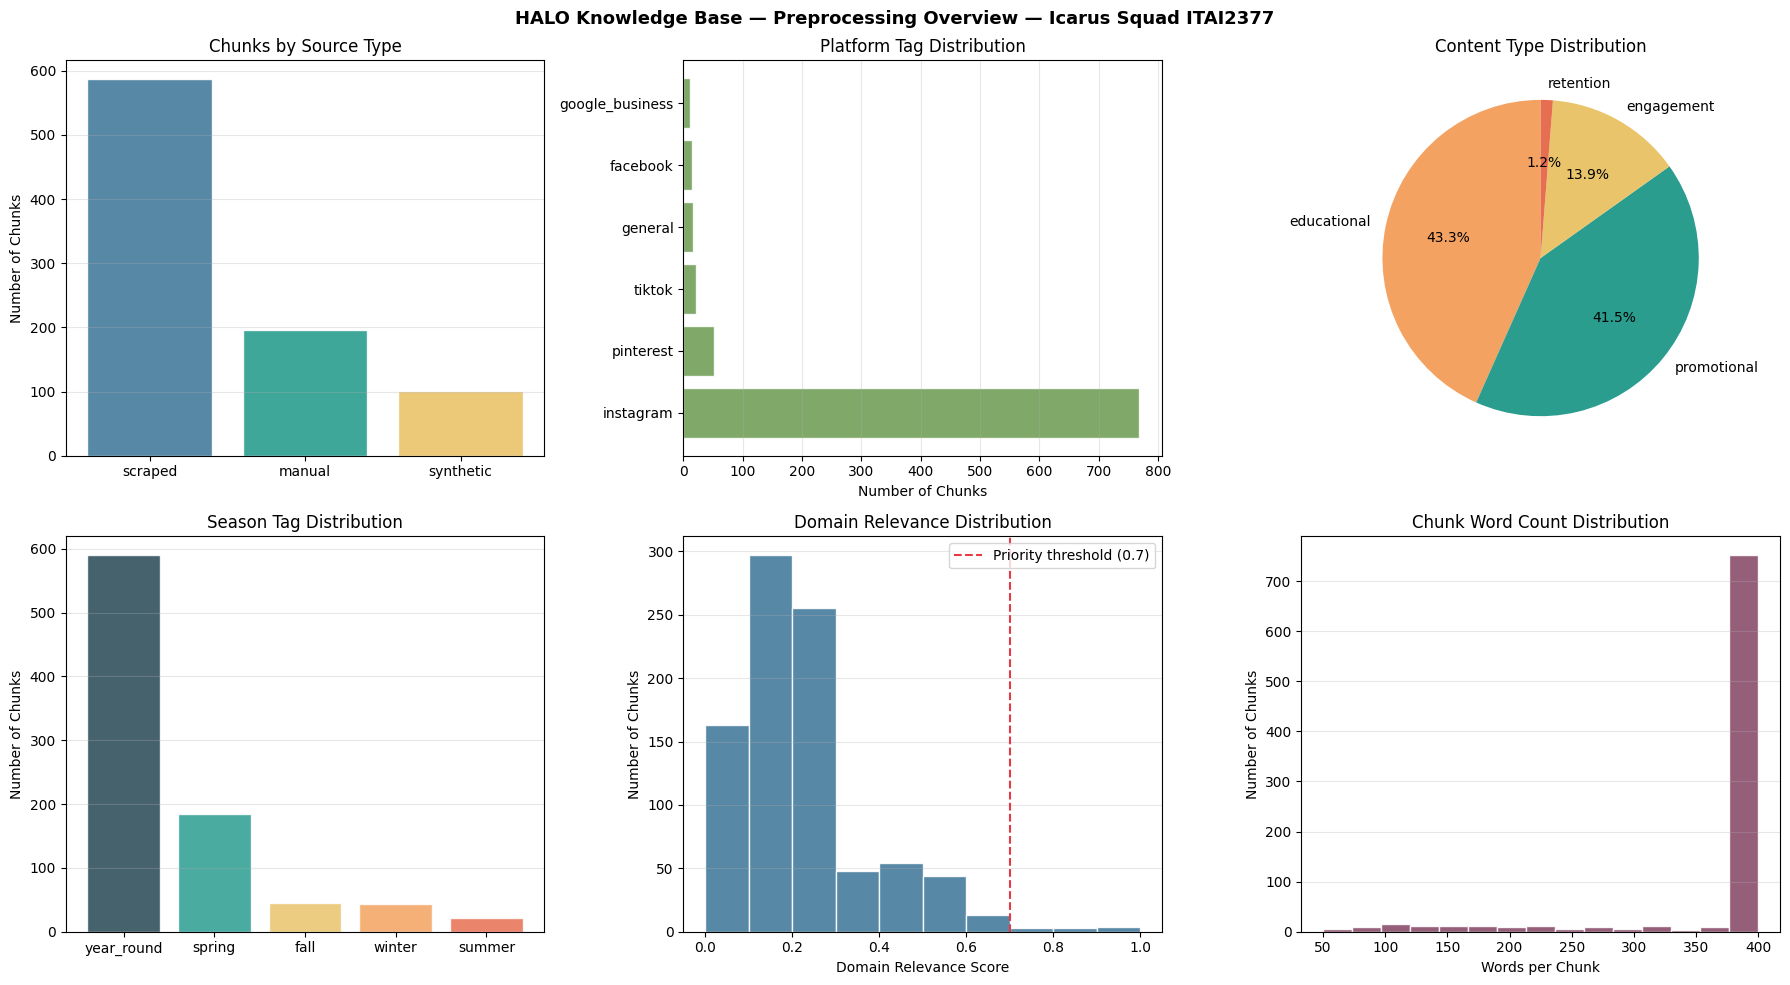

Visualization saved to: /content/drive/MyDrive/HALO_Project/visualizations/preprocessing_overview.png


In [20]:
# Cell 17: Visualizations
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle(
    'HALO Knowledge Base — Preprocessing Overview — Icarus Squad ITAI2377',
    fontsize=13, fontweight='bold'
)

# Chart 1: Source type breakdown
tc = df_chunks['source_type'].value_counts()
axes[0,0].bar(tc.index, tc.values,
              color=['#457b9d','#2a9d8f','#e9c46a'], edgecolor='white', alpha=0.9)
axes[0,0].set_ylabel('Number of Chunks')
axes[0,0].set_title('Chunks by Source Type')
axes[0,0].grid(axis='y', alpha=0.3)

# Chart 2: Platform distribution
pc = df_chunks['platform_tag'].value_counts()
axes[0,1].barh(pc.index, pc.values, color='#6a994e', alpha=0.85, edgecolor='white')
axes[0,1].set_xlabel('Number of Chunks')
axes[0,1].set_title('Platform Tag Distribution')
axes[0,1].grid(axis='x', alpha=0.3)

# Chart 3: Content type pie
ct     = df_chunks['content_type_tag'].value_counts()
colors = ['#f4a261','#2a9d8f','#e9c46a','#e76f51']
axes[0,2].pie(ct.values, labels=ct.index,
              colors=colors[:len(ct)], autopct='%1.1f%%', startangle=90)
axes[0,2].set_title('Content Type Distribution')

# Chart 4: Season distribution
sc            = df_chunks['season_tag'].value_counts()
season_colors = ['#264653','#2a9d8f','#e9c46a','#f4a261','#e76f51']
axes[1,0].bar(sc.index, sc.values,
              color=season_colors[:len(sc)], alpha=0.85, edgecolor='white')
axes[1,0].set_ylabel('Number of Chunks')
axes[1,0].set_title('Season Tag Distribution')
axes[1,0].grid(axis='y', alpha=0.3)

# Chart 5: Domain relevance histogram
axes[1,1].hist(df_chunks['domain_relevance_score'], bins=10,
               color='#457b9d', edgecolor='white', alpha=0.9)
axes[1,1].axvline(x=0.7, color='#e63946', linestyle='--',
                  linewidth=1.5, label='Priority threshold (0.7)')
axes[1,1].set_xlabel('Domain Relevance Score')
axes[1,1].set_ylabel('Number of Chunks')
axes[1,1].set_title('Domain Relevance Distribution')
axes[1,1].legend()
axes[1,1].grid(axis='y', alpha=0.3)

# Chart 6: Word count distribution
axes[1,2].hist(df_chunks['word_count'], bins=15,
               color='#8b4e6b', edgecolor='white', alpha=0.9)
axes[1,2].set_xlabel('Words per Chunk')
axes[1,2].set_ylabel('Number of Chunks')
axes[1,2].set_title('Chunk Word Count Distribution')
axes[1,2].grid(axis='y', alpha=0.3)

plt.tight_layout()
viz_path = f'{BASE_DIR}/visualizations/preprocessing_overview.png'
plt.savefig(viz_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Visualization saved to: {viz_path}')

---
## Step 8 — Generate Sentence Embeddings

**Cell explanation:** This cell converts every chunk of text into a 384-dimensional
numeric vector that captures its semantic meaning rather than just its exact words.
This is what makes HALO's retrieval semantic rather than keyword-based — it can
find a chunk about 'holiday color deals' even if the user asks about 'Christmas
hair specials' because the meanings are similar even though the words differ.

The model used is `all-MiniLM-L6-v2` from Hugging Face. It is a lightweight,
high-quality sentence transformer that runs efficiently on Colab's free T4 GPU.
It downloads approximately 80MB on the first run and uses a local cache afterward.

This same model must be used in Notebooks 2 and 3 when encoding user queries.
Using a different model would produce incompatible vectors and break retrieval.

In [21]:
# Cell 18: Generate Sentence Embeddings
print('Loading sentence transformer model (all-MiniLM-L6-v2)...')
print('This downloads ~80MB on first run, then uses a local cache.')
embedding_model = SentenceTransformer('all-MiniLM-L6-v2')
print('Model loaded.')

chunk_texts = [c['text'] for c in all_chunks]
print(f'\nGenerating embeddings for {len(chunk_texts)} chunks...')
print('This step benefits from GPU runtime (Runtime → Change runtime type → T4 GPU)')

embeddings = embedding_model.encode(
    chunk_texts,
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True
)

print(f'\nEmbeddings generated.')
print(f'  Shape: {embeddings.shape}')
print(f'  Each chunk = {embeddings.shape[1]}-dimensional vector')

Loading sentence transformer model (all-MiniLM-L6-v2)...
This downloads ~80MB on first run, then uses a local cache.


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model loaded.

Generating embeddings for 884 chunks...
This step benefits from GPU runtime (Runtime → Change runtime type → T4 GPU)


Batches:   0%|          | 0/28 [00:00<?, ?it/s]


Embeddings generated.
  Shape: (884, 384)
  Each chunk = 384-dimensional vector


---
## Step 9 — Store in ChromaDB

**Cell explanation:** This cell saves all chunks, their metadata tags, and their
embedding vectors into ChromaDB — a local vector database persisted to Google Drive.

ChromaDB was chosen because it runs entirely locally with no cloud account or
external server required. It integrates directly with the retrieval functions
in Notebooks 2 and 3 via its Python API.

The collection is rebuilt from scratch each time this cell runs by deleting the
existing collection first. This ensures ChromaDB always reflects the current
state of the knowledge base after any updates to source files.

Data is inserted in batches of 50 chunks to stay within ChromaDB's recommended
limits for a single add operation.

In [22]:
# Cell 19: Store in ChromaDB
chroma_path   = f'{BASE_DIR}/chromadb'
chroma_client = chromadb.PersistentClient(path=chroma_path)

# Delete existing collection to rebuild fresh
# This ensures ChromaDB reflects all current source files
try:
    chroma_client.delete_collection('halo_knowledge_base')
    print('Existing collection removed. Rebuilding fresh.')
except Exception:
    print('No existing collection found. Creating new.')

collection = chroma_client.create_collection(
    name='halo_knowledge_base',
    metadata={'description': 'HALO marketing assistant KB — Icarus Squad ITAI2377'}
)

BATCH_SIZE = 50
for i in tqdm(range(0, len(all_chunks), BATCH_SIZE), desc='Storing chunks'):
    batch     = all_chunks[i:i + BATCH_SIZE]
    batch_emb = embeddings[i:i + BATCH_SIZE]
    collection.add(
        ids=[c['chunk_id'] for c in batch],
        documents=[c['text'] for c in batch],
        embeddings=batch_emb.tolist(),
        metadatas=[{
            'source_file':            c['source_file'],
            'source_type':            c['source_type'],
            'chunk_index':            c['chunk_index'],
            'platform_tag':           c['platform_tag'],
            'season_tag':             c['season_tag'],
            'content_type_tag':       c['content_type_tag'],
            'domain_relevance_score': c['domain_relevance_score'],
            'length_label':           c['length_label'],
            'word_count':             c['word_count']
        } for c in batch]
    )

total_stored = collection.count()
print(f'\nChromaDB storage complete.')
print(f'  Chunks stored: {total_stored}')
print(f'  Database path: {chroma_path}')

Existing collection removed. Rebuilding fresh.


Storing chunks: 100%|██████████| 18/18 [00:08<00:00,  2.16it/s]


ChromaDB storage complete.
  Chunks stored: 884
  Database path: /content/drive/MyDrive/HALO_Project/chromadb


---
## Step 10 — Retrieval Sanity Check

**Cell explanation:** This cell verifies that the ChromaDB collection is working
correctly by running 5 representative test queries and printing the top retrieved
chunk for each. This is the component-level test described in the midterm
evaluation plan — it confirms the retrieval system is working before the full
pipeline in Notebook 2 is run.

What to look for in the results:
- The top chunk text should be semantically related to the query
- The platform and content type tags should match the query context
- Similarity scores above 0.5 indicate good retrieval quality
- If scores are very low (below 0.3), the knowledge base may need more content
  on that topic or the query may need to be rephrased

In [23]:
# Cell 20: Retrieval Sanity Check
TEST_QUERIES = [
    ('Write me an Instagram caption for a summer balayage special', 'instagram', 'promotional'),
    ('What does engagement rate mean?',                            None,        'educational'),
    ('Help me plan a holiday gift card promotion',                 None,        'promotional'),
    ('Write a rebooking message for a client I have not seen in 2 months', None, 'retention'),
    ('What TikTok content should I make as a hairstylist?',       'tiktok',    None),
]

print('RETRIEVAL SANITY CHECK — Top Result per Test Query')
print('=' * 60)
scores = []

for query, platform, ctype in TEST_QUERIES:
    results = retrieve_chunks(query, n_results=3,
                              platform_filter=platform,
                              content_type_filter=ctype)
    top = results[0] if results else None
    print(f'\nQuery: {query}')
    if top:
        m = top['metadata']
        print(f'  Top chunk: {top["text"][:120]}...')
        print(f'  Source:     {m["source_file"]} ({m["source_type"]})')
        print(f'  Tags:       platform={m["platform_tag"]} | '
              f'season={m["season_tag"]} | type={m["content_type_tag"]}')
        print(f'  Similarity: {top["similarity_score"]}')
        scores.append(top["similarity_score"])
    else:
        print('  No results — add more source files and re-run from Step 3.')

if scores:
    avg = sum(scores) / len(scores)
    print(f'\nAverage similarity score: {avg:.4f}')
    if avg < 0.3:
        print('Scores are low — consider adding more source content.')
    elif avg < 0.5:
        print('Scores are moderate — knowledge base is functional.')
    else:
        print('Scores are good — knowledge base is ready for Notebook 2.')

RETRIEVAL SANITY CHECK — Top Result per Test Query

Query: Write me an Instagram caption for a summer balayage special
  Top chunk: in the caption or in the first comment. instagram treats both options the same in most cases, so choose whichever feels ...
  Source:     synthetic_hashtag_strategy_instagram.txt (synthetic)
  Tags:       platform=instagram | season=year_round | type=promotional
  Similarity: 0.5634

Query: What does engagement rate mean?
  Top chunk: table of contents key takeaways - engagement rate measures how many people interact with your social content, not just s...
  Source:     hootsuite_instagram_engagement_rate.txt (scraped)
  Tags:       platform=instagram | season=year_round | type=educational
  Similarity: 0.5825

Query: Help me plan a holiday gift card promotion
  Top chunk: or a client smiling after an appointment is more persuasive than a plain graphic. people want to imagine the experience,...
  Source:     synthetic_gift_card_promotion_guide.txt (synthet

---
## Step 11 — Save Processed Chunks to CSV

**Cell explanation:** This cell exports all processed chunks and their metadata
to a CSV file on Google Drive. This serves two purposes:

1. **Backup** — if ChromaDB ever needs to be rebuilt, the CSV contains all
   the processed text and metadata without needing to re-run Steps 1-9
2. **Inspection** — the CSV can be opened in Google Sheets to manually review
   chunk content, tag assignments, and domain relevance scores, which is
   useful for identifying and fixing tagging errors before the evaluation

In [24]:
# Cell 21: Save Processed Chunks to CSV
csv_path  = f'{BASE_DIR}/processed_chunks/halo_chunks.csv'
df_export = df_chunks[[
    'chunk_id','source_file','source_type','chunk_index','word_count',
    'platform_tag','season_tag','content_type_tag',
    'domain_relevance_score','length_label','text'
]].copy()
df_export.to_csv(csv_path, index=False)

print(f'Processed chunks saved to: {csv_path}')
print(f'Rows: {len(df_export)} | Columns: {len(df_export.columns)}')
display(df_export.head(5))

Processed chunks saved to: /content/drive/MyDrive/HALO_Project/processed_chunks/halo_chunks.csv
Rows: 884 | Columns: 11


,chunk_id,source_file,source_type,chunk_index,word_count,platform_tag,season_tag,content_type_tag,domain_relevance_score,length_label,text
0,ads_2025_beauty_blog_tiktok_smb_chunk_000,ads_2025_beauty_blog_tiktok_smb.txt,manual,0,400,instagram,year_round,educational,0.200,long,"data-backed insights, content tips, and campai..."
1,ads_2025_beauty_blog_tiktok_smb_chunk_001,ads_2025_beauty_blog_tiktok_smb.txt,manual,1,400,instagram,summer,educational,0.250,long,your smb should be keeping in mind when creati...
2,ads_2025_beauty_blog_tiktok_smb_chunk_002,ads_2025_beauty_blog_tiktok_smb.txt,manual,2,193,instagram,year_round,engagement,0.144,medium,what works and boosting it. proven to deliver ...
3,ads_google_ads_tips_chunk_000,ads_google_ads_tips.txt,manual,0,155,instagram,spring,promotional,0.161,medium,spend ion-cyo-target-amount with google ads in...
4,ads_how_to_advertise_on_google_chunk_000,ads_how_to_advertise_on_google.txt,manual,0,400,instagram,year_round,promotional,0.100,long,"drive sales, stand out, be found, show up, wit..."


---
## Step 12 — Feature Importance Analysis

**Cell explanation:** This cell analyzes how much each engineered feature
contributes to retrieval quality. Feature importance is measured by how well
each tag differentiates chunks — a tag with high variety and even distribution
is more useful for filtering than one where 90% of chunks have the same value.

The qualitative ranking at the end is used in the report's Feature Engineering
section to justify which features are most impactful and why.

In [25]:
# Cell 22: Feature Importance Analysis
print('FEATURE IMPORTANCE ANALYSIS')
print('=' * 55)

print('\n1. Domain Relevance Score (numeric, 0-1)')
print(f"   Mean:                     {df_chunks['domain_relevance_score'].mean():.3f}")
print(f"   Median:                   {df_chunks['domain_relevance_score'].median():.3f}")
print(f"   Std Dev:                  {df_chunks['domain_relevance_score'].std():.3f}")
high = (df_chunks['domain_relevance_score'] > 0.7).sum()
print(f"   Above priority threshold: {high} chunks ({high/len(df_chunks)*100:.1f}%)")

for feat, label in [
    ('platform_tag',     '2. Platform Tag (categorical)'),
    ('content_type_tag', '3. Content Type Tag (categorical)'),
    ('season_tag',       '4. Season Tag (categorical)'),
    ('length_label',     '5. Length Label (categorical)'),
    ('source_type',      'Source Type Breakdown'),
]:
    print(f'\n{label}')
    for tag, count in df_chunks[feat].value_counts().items():
        bar = '|' * int(count / len(df_chunks) * 30)
        print(f'   {tag:<20} {count:>4} chunks ({count/len(df_chunks)*100:>5.1f}%)  {bar}')

print('\n' + '=' * 55)
print('Feature Ranking (most to least impactful for retrieval quality):')
print('''
  1. domain_relevance_score  — Highest impact. Directly filters out
     generic marketing content, keeping responses beauty-specific.

  2. content_type_tag        — High impact. Aligns chunk intent with
     user intent (e.g. retention query gets retention chunks).

  3. platform_tag            — High impact for platform-specific requests.
     Less relevant for general marketing questions.

  4. season_tag              — Moderate impact. Critical for campaign
     planning; less relevant for evergreen questions.

  5. length_label            — Supporting role. Guides response length
     rather than retrieval selection.
''')

FEATURE IMPORTANCE ANALYSIS

1. Domain Relevance Score (numeric, 0-1)
   Mean:                     0.209
   Median:                   0.150
   Std Dev:                  0.162
   Above priority threshold: 10 chunks (1.1%)

2. Platform Tag (categorical)
   instagram             769 chunks ( 87.0%)  ||||||||||||||||||||||||||
   pinterest              51 chunks (  5.8%)  |
   tiktok                 22 chunks (  2.5%)  
   general                16 chunks (  1.8%)  
   facebook               15 chunks (  1.7%)  
   google_business        11 chunks (  1.2%)  

3. Content Type Tag (categorical)
   educational           383 chunks ( 43.3%)  ||||||||||||
   promotional           367 chunks ( 41.5%)  ||||||||||||
   engagement            123 chunks ( 13.9%)  ||||
   retention              11 chunks (  1.2%)  

4. Season Tag (categorical)
   year_round            590 chunks ( 66.7%)  ||||||||||||||||||||
   spring                184 chunks ( 20.8%)  ||||||
   fall                   45 chunks (  

---
## Notebook 1 Complete

| Step | Component | Output |
|---|---|---|
| 1 | Dependencies | Libraries installed |
| 2 | Drive mount + imports | Working directory confirmed |
| 2.5 | Web scraper | `.txt` files from article URLs |
| 2.6 | Synthetic generator | `.txt` files from GenAI |
| 2.7 | Collection summary | Chunk count estimate |
| 3 | Document loading | `documents` list |
| 4 | Text cleaning | `clean_text` per document |
| 5 | Chunking | `all_chunks` list |
| 6 | Feature engineering | 5 tags per chunk |
| 7 | Quality metrics + charts | Saved to `/visualizations/` |
| 8 | Sentence embeddings | `embeddings` numpy array |
| 9 | ChromaDB storage | Persisted to `/chromadb/` |
| 10 | Retrieval sanity check | 5 test queries passed |
| 11 | CSV export | Saved to `/processed_chunks/` |
| 12 | Feature importance | Analysis printed |

### Team Checklist
- [ ] Each member adds Drive shortcut to `HALO_Project` (see title cell)
- [ ] Each member adds free `GEMINI_API_KEY` to Colab Secrets for Step 2.6
- [ ] Run Steps 1-9 in order using T4 GPU runtime
- [ ] Check chunk count at end of Step 5 — target is 500-800
- [ ] If below 500, add URLs to Step 2.5 or topics to Step 2.6 and re-run
- [ ] Confirm Step 10 retrieval scores are above 0.3 before proceeding
- [ ] Proceed to Notebook 2 once ChromaDB is saved and sanity check passes